# Week-2 Assignment: Fruit Freshness Detection
- Aashik kumar Jha 
- Presidential Graduate School, Kathmandu
- TECH 405: Artificial Neural Network & Deep Learning
- Prof. Aashish Dhakal 
- July 13, 2026


# Fruit Freshness Dataset EDA and Preprocessing

For this project, the Fruits-360 Dataset, which is an open-access image dataset available from Kaggle, is utilized for conducting Exploratory Data Analysis (EDA) and performing basic feature engineering as required in a Neural Networks assignment. The Fruits-360 dataset comprises 182,945 images belonging to 260 different classes of fruits. The dataset consists of both Training and Test folders and all images have .jpg extension with the dimensions of 100 x 100 pixels.

The key aim of this notebook is to provide a beginner-friendly introduction to the Fruits-360 dataset and its features. The notebook will also demonstrate how to perform basic preprocessing steps such as resizing, normalization, and label encoding to prepare the data for further analysis. This notebook serves as a starting point for the assignment report and will be updated as the project progresses.

## 1. Import Libraries and Find the Dataset

In this section, we import the libraries we need and automatically locate the dataset folder inside the workspace.

In [1]:
from pathlib import Path
from collections import Counter
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 120)

random.seed(42)
np.random.seed(42)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}
TARGET_SIZE = (100, 100)

def find_dataset_root():
    # Search the current workspace and its parents for a dataset that has Training and Test folders.
    search_roots = [Path.cwd()] + list(Path.cwd().parents)
    for base in search_roots:
        data_dir = base / "Data"
        if not data_dir.exists():
            continue
        for train_dir in data_dir.rglob("Training"):
            if train_dir.is_dir() and (train_dir.parent / "Test").is_dir():
                return train_dir.parent
    raise FileNotFoundError("Could not find a dataset folder with Training and Test subfolders.")

def list_class_dirs(split_dir):
    # Return all class folders in a split directory.
    return sorted([p for p in split_dir.iterdir() if p.is_dir()], key=lambda p: p.name.lower())

def list_image_files(folder):
    # Return only image files from one class folder.
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])

def open_rgb(image_path):
    # Open an image and convert it to RGB.
    with Image.open(image_path) as img:
        return img.convert("RGB")

def preprocess_image(image_path, target_size=TARGET_SIZE):
    # Resize the image to a fixed size and normalize pixel values to 0-1.
    image = open_rgb(image_path).resize(target_size)
    return np.asarray(image, dtype=np.float32) / 255.0

dataset_root = find_dataset_root()
train_dir = dataset_root / "Training"
test_dir = dataset_root / "Test"

print("Dataset name:", f"{dataset_root.parent.name} / {dataset_root.name}")
print("Dataset root:", dataset_root)
print("Training folder:", train_dir)
print("Testing folder:", test_dir)

Dataset name: fruits-360_original-size / fruits-360-original-size
Dataset root: d:\FoodFreshnessDetectation\Data\fruits-360_original-size\fruits-360-original-size
Training folder: d:\FoodFreshnessDetectation\Data\fruits-360_original-size\fruits-360-original-size\Training
Testing folder: d:\FoodFreshnessDetectation\Data\fruits-360_original-size\fruits-360-original-size\Test


## 2. Dataset Overview

Here we inspect the dataset structure, count the images in each class, and build a summary table.

In [2]:
# Collect class names from both splits.
train_classes = list_class_dirs(train_dir)
test_classes = list_class_dirs(test_dir)
class_names = sorted(set([p.name for p in train_classes] + [p.name for p in test_classes]))

# Count images per class and record the image formats and sizes.
image_format_counter = Counter()
size_counter = Counter()
class_rows = []

for class_name in class_names:
    train_class_dir = train_dir / class_name
    test_class_dir = test_dir / class_name

    train_files = list_image_files(train_class_dir) if train_class_dir.exists() else []
    test_files = list_image_files(test_class_dir) if test_class_dir.exists() else []
    total_files = train_files + test_files

    for image_path in total_files:
        image_format_counter[image_path.suffix.lower()] += 1

    if total_files:
        first_image = total_files[0]
        try:
            with Image.open(first_image) as img:
                size_counter[f"{img.width}x{img.height}"] += 1
        except Exception:
            pass

    class_rows.append(
        {
            "Class Name": class_name,
            "Training Images": len(train_files),
            "Testing Images": len(test_files),
            "Total Images": len(total_files),
        }
    )

summary_df = pd.DataFrame(class_rows).sort_values("Class Name").reset_index(drop=True)
overview_df = pd.DataFrame(
    [
        ["Dataset Name", f"{dataset_root.parent.name} / {dataset_root.name}"],
        ["Number of Classes", int(summary_df.shape[0])],
        ["Training Images", int(summary_df["Training Images"].sum())],
        ["Testing Images", int(summary_df["Testing Images"].sum())],
        ["Total Images", int(summary_df["Total Images"].sum())],
        ["Folder Structure", "Data/fruits-360_100x100/fruits-360/Training/<class>/image.jpg and Test/<class>/image.jpg"],
        ["Image Formats", ", ".join(sorted(image_format_counter.keys()))],
        ["Image Size / Resolution", ", ".join([f"{k}: {v}" for k, v in size_counter.items()])],
    ],
    columns=["Item", "Value"],
)

print("Brief dataset overview")
display(overview_df)

print("Summary table for each class")
display(summary_df)

print("Useful summary information")
print("Number of classes:", int(summary_df.shape[0]))
print("Total number of images:", int(summary_df["Total Images"].sum()))
print("Image formats found:", dict(image_format_counter))
print("Image size / resolution found:", dict(size_counter))
print("Smallest class size:", int(summary_df["Total Images"].min()))
print("Largest class size:", int(summary_df["Total Images"].max()))
print("Average images per class:", round(float(summary_df["Total Images"].mean()), 2))

Brief dataset overview


,Item,Value
0,Dataset Name,fruits-360_original-size / fruits-360-original-size
1,Number of Classes,147
2,Training Images,51345
3,Testing Images,25526
4,Total Images,76871
5,Folder Structure,Data/fruits-360_100x100/fruits-360/Training/<class>/image.jpg and Test/<class>/image.jpg
6,Image Formats,.jpg
7,Image Size / Resolution,"294x142: 1, 447x399: 1, 370x340: 1, 767x813: 1, 749x750: 1, 664x683: 1, 592x510: 1, 524x484: 1, 550x510: 1, 799x889:..."


Summary table for each class


,Class Name,Training Images,Testing Images,Total Images
0,Almonds 1,155,77,232
1,Apple 10,465,231,696
2,Apple 11,287,142,429
3,Apple 12,310,154,464
4,Apple 13,465,231,696
...,...,...,...,...
142,apple_red_delicios_1,300,150,450
143,apple_red_yellow_1,308,154,462
144,cabbage_white_1,96,47,143
145,eggplant_long_1,160,80,240


Useful summary information
Number of classes: 147
Total number of images: 76871
Image formats found: {'.jpg': 76871}
Image size / resolution found: {'294x142': 1, '447x399': 1, '370x340': 1, '767x813': 1, '749x750': 1, '664x683': 1, '592x510': 1, '524x484': 1, '550x510': 1, '799x889': 1, '343x318': 1, '515x580': 1, '272x608': 1, '338x318': 1, '320x261': 1, '453x608': 1, '578x515': 1, '433x478': 1, '479x420': 1, '238x209': 1, '298x477': 1, '381x485': 1, '310x515': 1, '513x824': 1, '178x582': 1, '553x127': 1, '606x102': 1, '231x302': 1, '330x214': 1, '257x218': 1, '182x238': 1, '197x278': 1, '660x762': 1, '263x530': 1, '261x430': 1, '65x82': 1, '664x750': 1, '366x247': 1, '405x219': 1, '199x633': 1, '312x500': 1, '495x588': 1, '228x221': 1, '281x246': 1, '197x202': 1, '287x292': 1, '275x263': 1, '147x114': 1, '302x318': 1, '306x314': 1, '180x178': 1, '347x362': 1, '324x798': 1, '433x671': 1, '349x738': 1, '427x257': 1, '191x774': 1, '321x1047': 1, '249x975': 1, '267x867': 1, '340x757': 1

## 3. Exploratory Data Analysis (EDA)

This section displays the class names and a few useful summary values.

In [3]:
class_names_df = pd.DataFrame({"Class Name": class_names})
eda_df = summary_df[["Class Name", "Total Images"]].copy()

print("Class names:")
display(class_names_df)

print("EDA DataFrame:")
display(eda_df)

print("Descriptive statistics for image counts per class:")
display(eda_df["Total Images"].describe())

print("Top 10 classes by image count:")
display(eda_df.sort_values("Total Images", ascending=False).head(10))

Class names:


,Class Name
0,Almonds 1
1,Apple 10
2,Apple 11
3,Apple 12
4,Apple 13
...,...
142,apple_red_delicios_1
143,apple_red_yellow_1
144,cabbage_white_1
145,eggplant_long_1


EDA DataFrame:


,Class Name,Total Images
0,Almonds 1,232
1,Apple 10,696
2,Apple 11,429
3,Apple 12,464
4,Apple 13,696
...,...,...
142,apple_red_delicios_1,450
143,apple_red_yellow_1,462
144,cabbage_white_1,143
145,eggplant_long_1,240


Descriptive statistics for image counts per class:


count    147.000000
mean     522.931973
std      214.816668
min       77.000000
25%      401.500000
50%      477.000000
75%      699.000000
max      968.000000
Name: Total Images, dtype: float64

Top 10 classes by image count:


,Class Name,Total Images
41,Cherimoya 1,968
38,Carambola 3,960
62,Dates 2,958
79,Orange 4,948
98,Pear 9,928
58,Cucumber 6,925
82,Peach 3,924
74,Onion 2,765
112,Quince 4,749
21,Avocado Black 2,738


## 4. Visualizations

The following charts and images help us understand the dataset better.

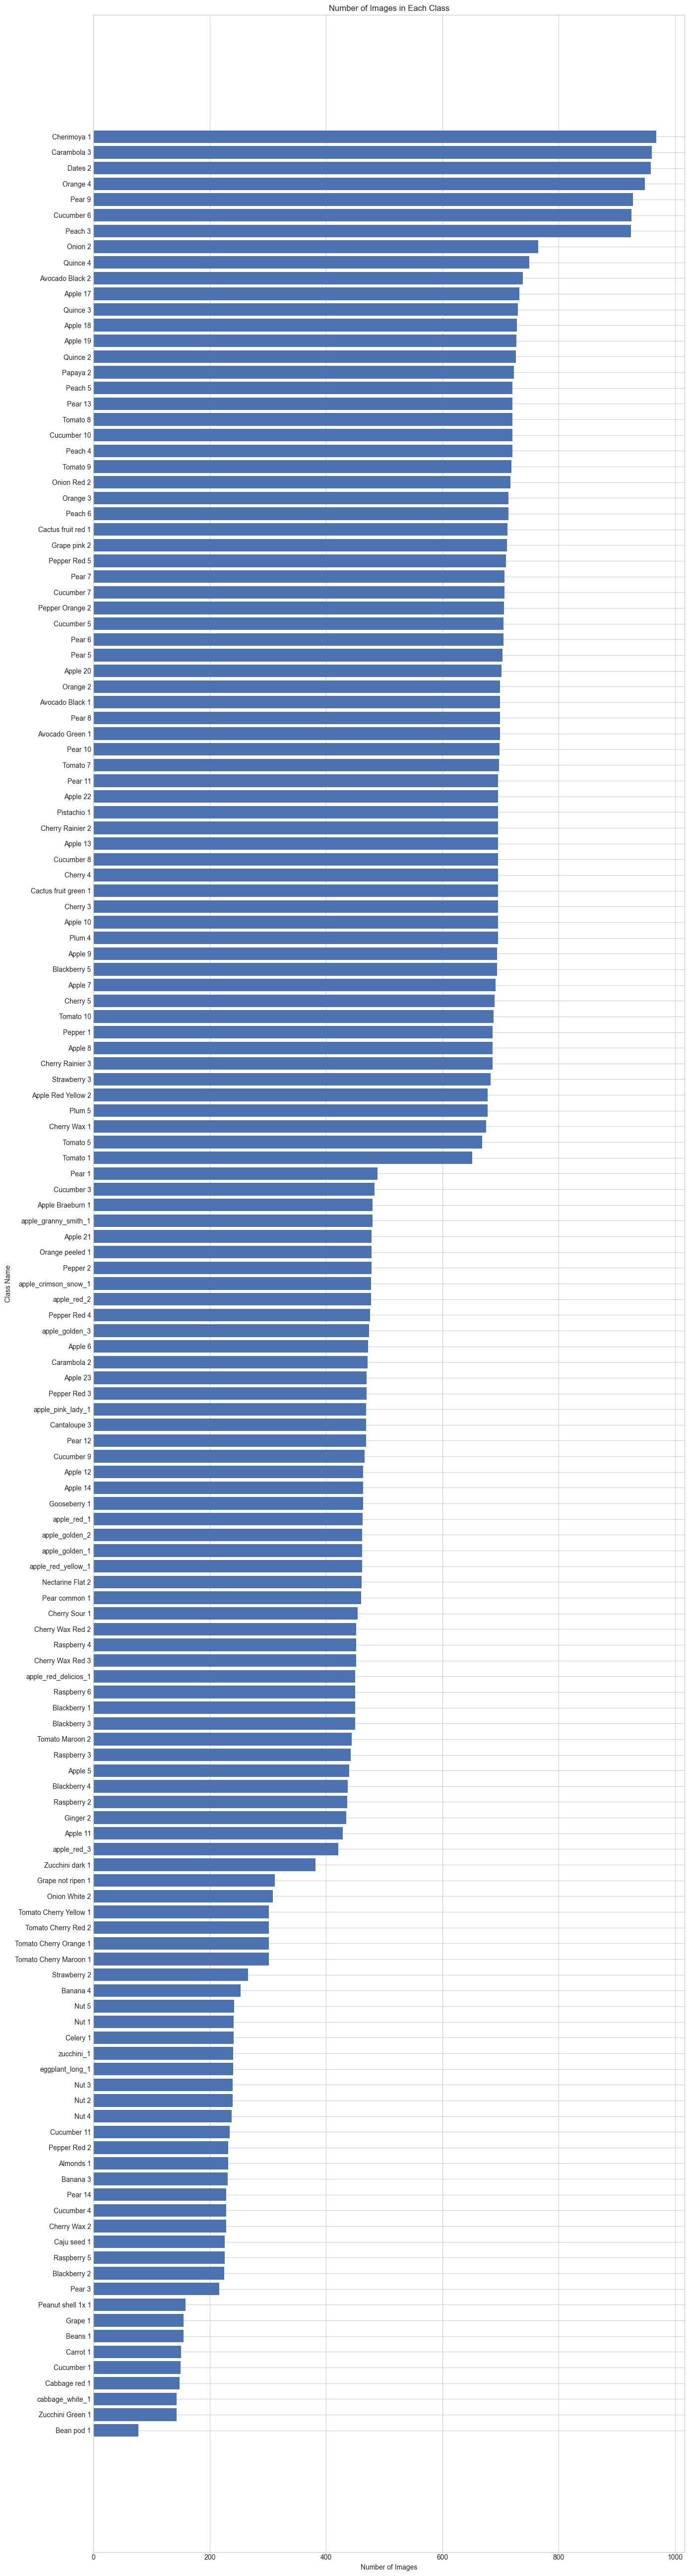

In [4]:
# Bar chart of image counts for all classes.
plot_df = summary_df.sort_values("Total Images", ascending=True)

plt.figure(figsize=(14, 52))
plt.barh(plot_df["Class Name"], plot_df["Total Images"], color="#4C72B0")
plt.title("Number of Images in Each Class")
plt.xlabel("Number of Images")
plt.ylabel("Class Name")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

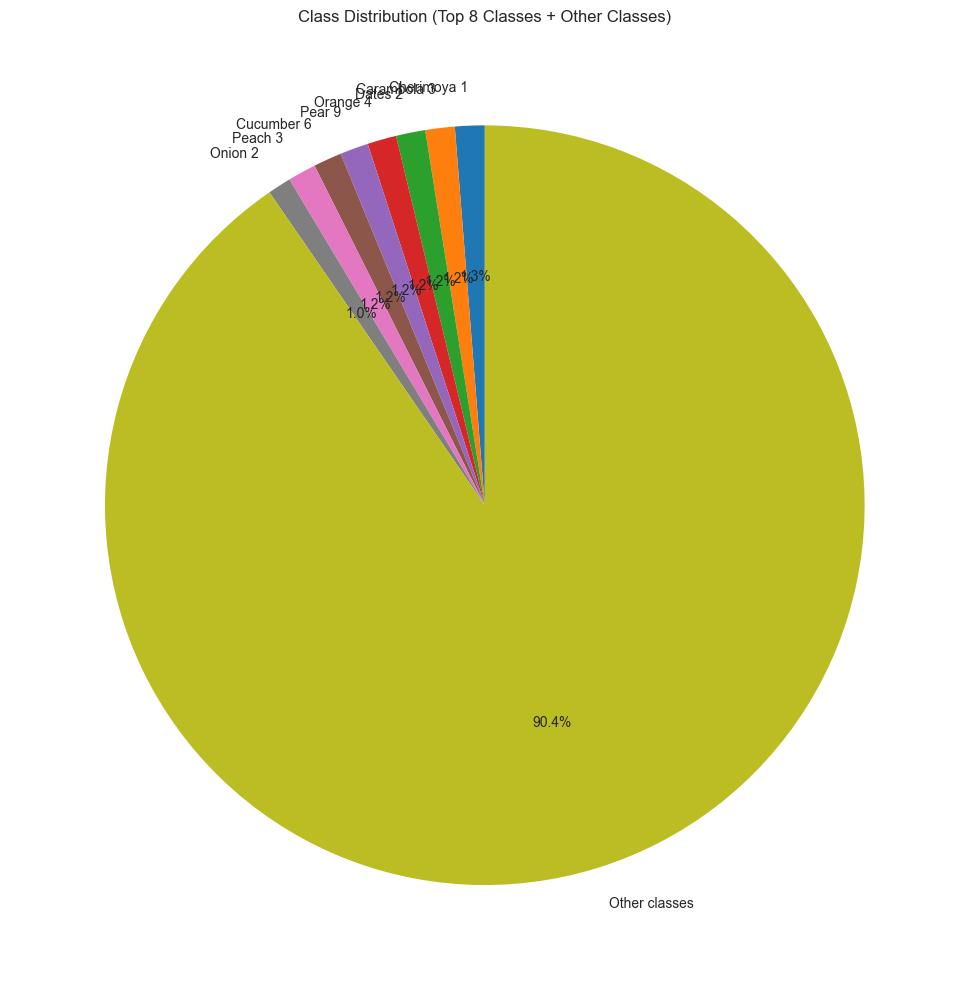

In [5]:
# Pie chart for the class distribution.
# A full pie chart with 260 classes would be too crowded, so we show the top 8 classes and group the rest as Other classes.
top_n = 8
pie_source = summary_df.sort_values("Total Images", ascending=False).reset_index(drop=True)
top_classes = pie_source.head(top_n).copy()
other_count = int(pie_source["Total Images"].iloc[top_n:].sum())

pie_labels = top_classes["Class Name"].tolist() + ["Other classes"]
pie_values = top_classes["Total Images"].tolist() + [other_count]

plt.figure(figsize=(10, 10))
plt.pie(pie_values, labels=pie_labels, autopct="%1.1f%%", startangle=90)
plt.title("Class Distribution (Top 8 Classes + Other Classes)")
plt.tight_layout()
plt.show()

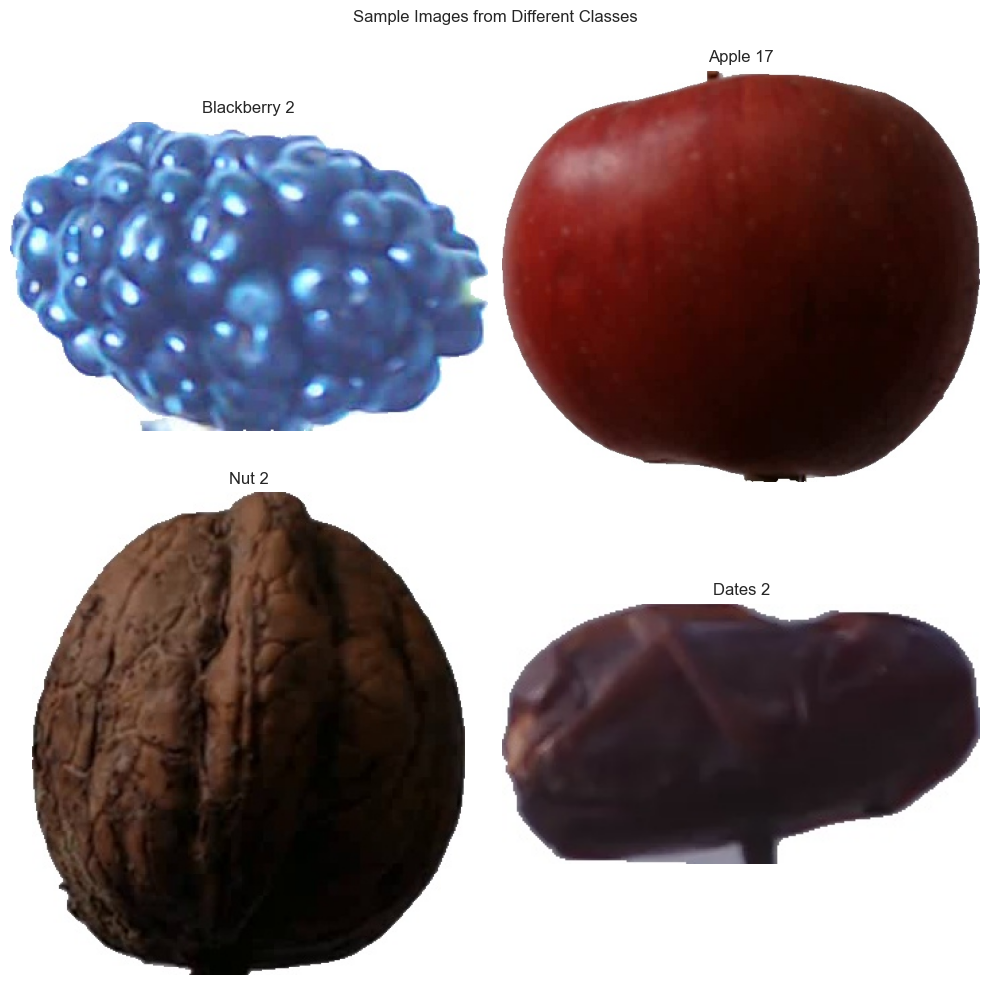

In [6]:
# Show a few sample images from different classes.
sample_classes = random.sample(class_names, k=4)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, class_name in zip(axes, sample_classes):
    class_dir = train_dir / class_name
    if not class_dir.exists():
        class_dir = test_dir / class_name

    image_files = list_image_files(class_dir)
    if not image_files:
        ax.axis("off")
        continue

    image_path = image_files[0]
    image = open_rgb(image_path)
    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.suptitle("Sample Images from Different Classes")
plt.tight_layout()
plt.show()

Image size / resolution table:


,Resolution,Count
0,294x142,1
1,447x399,1
2,370x340,1
3,767x813,1
4,749x750,1
...,...,...
142,544x568,1
143,333x324,1
144,763x722,1
145,143x644,1


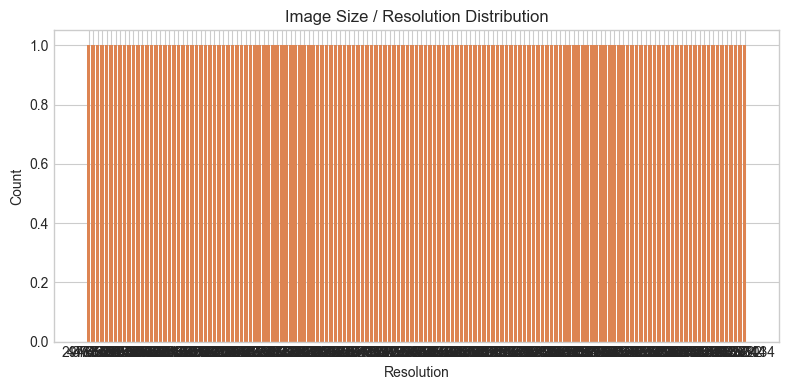

In [7]:
# Display the image size / resolution distribution.
size_df = pd.DataFrame([
    {"Resolution": size, "Count": count} for size, count in size_counter.items()
])

print("Image size / resolution table:")
display(size_df)

if not size_df.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(size_df["Resolution"], size_df["Count"], color="#DD8452")
    plt.title("Image Size / Resolution Distribution")
    plt.xlabel("Resolution")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## 5. Preprocessing / Feature Engineering

The images are already stored in a fixed size, but we still resize them to the same size during loading so every input has a consistent shape.
We also normalize pixel values to the range `0` to `1`, and we encode labels into numbers because neural networks work with numeric inputs.

Number of encoded classes: 147
First 10 label encodings:


,Class Name,Encoded Value
0,Almonds 1,0
1,Apple 10,1
2,Apple 11,2
3,Apple 12,3
4,Apple 13,4
5,Apple 14,5
6,Apple 17,6
7,Apple 18,7
8,Apple 19,8
9,Apple 20,9


Preprocessed sample batch shape: (4, 100, 100, 3)
Pixel value range after normalization: 0.0 to 1.0
Encoded sample labels: [ 57  35  26 139]


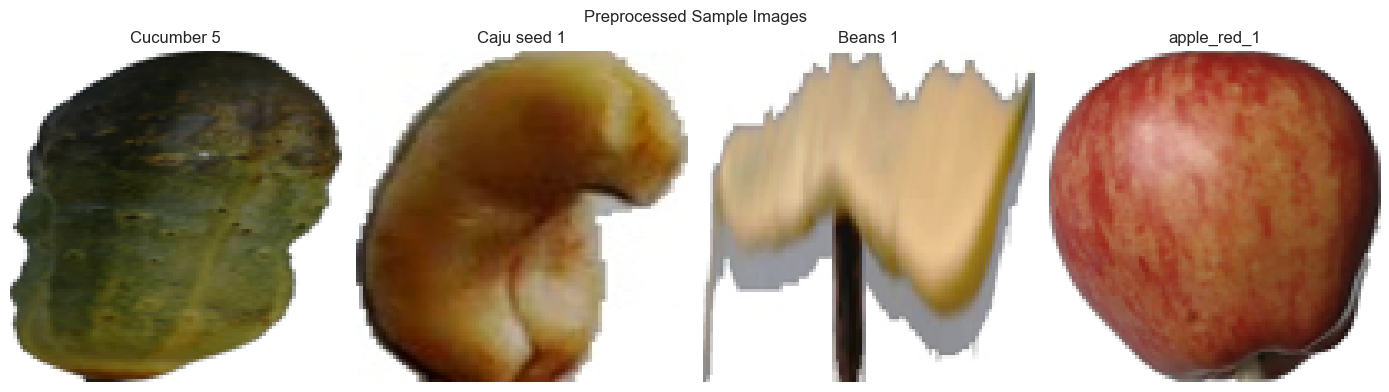

In [8]:
# Encode class labels to numbers.
label_encoder = LabelEncoder()
label_encoder.fit(class_names)

print("Number of encoded classes:", len(label_encoder.classes_))
print("First 10 label encodings:")
display(pd.DataFrame({
    "Class Name": label_encoder.classes_[:10],
    "Encoded Value": label_encoder.transform(label_encoder.classes_[:10])
}))

# Load a few sample images and preprocess them.
demo_classes = random.sample(class_names, k=4)
demo_paths = []
for class_name in demo_classes:
    class_dir = train_dir / class_name
    if not class_dir.exists():
        class_dir = test_dir / class_name
    demo_paths.append(list_image_files(class_dir)[0])

X_demo = np.stack([preprocess_image(path) for path in demo_paths])
y_demo = label_encoder.transform(demo_classes)

print("Preprocessed sample batch shape:", X_demo.shape)
print("Pixel value range after normalization:", float(X_demo.min()), "to", float(X_demo.max()))
print("Encoded sample labels:", y_demo)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, img_array, class_name in zip(axes, X_demo, demo_classes):
    ax.imshow(img_array)
    ax.set_title(class_name)
    ax.axis("off")
plt.suptitle("Preprocessed Sample Images")
plt.tight_layout()
plt.show()

## 6. Conclusion

Exploratory Data Analysis (EDA) together with feature engineering and data visualization were performed to analyze the Fruits-360 dataset. As a result of the analysis, useful information about the dataset structure, class distribution, image features, and the quality of the dataset in general was gathered. Visualizations revealed how the images are distributed among fruit classes, and image resizing, pixel normalization, and label encoding were used during the data preprocessing. the Fruits-360 dataset is structured well and can be used for classification of images of fruits via deep learning methods. Preprocessing and feature engineering have been performed successfully, so now the data is ready to be used for development of a Convolutional Neural Network (CNN).